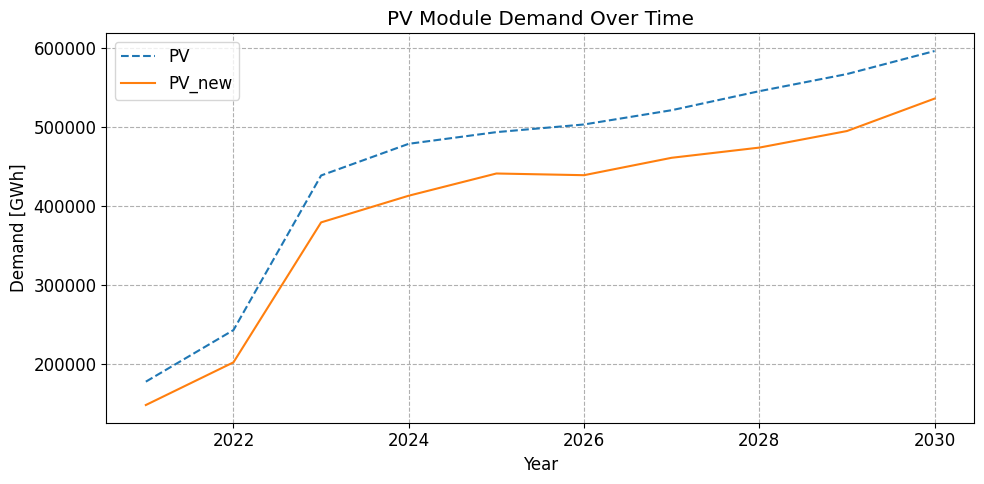

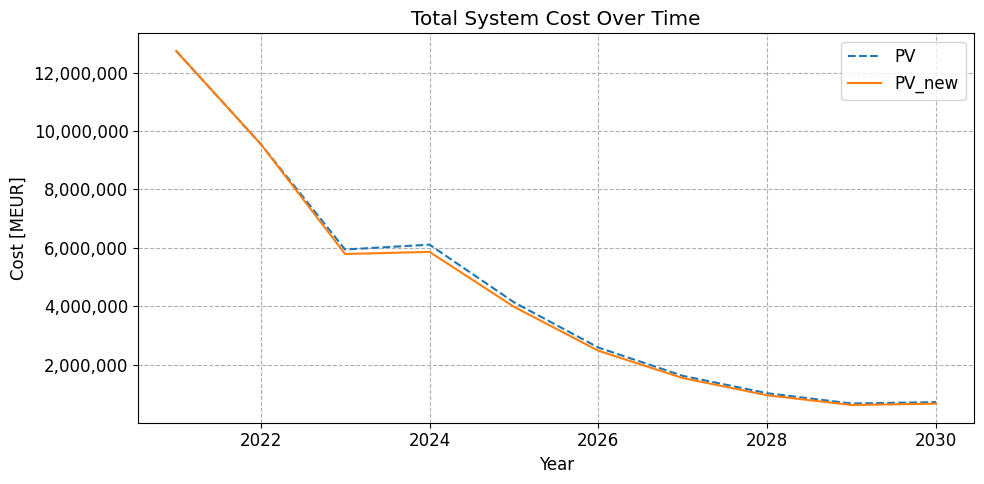

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
base_path = Path("outputs")
datasets = {
    "PV": base_path / "01_SP_MV_PV",
    "PV_new": base_path / "01_SP_MV_PV_new"
}
results = {label: Results(path) for label, path in datasets.items()}

# === Output Save Directory ===
save_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\ESM_plots\pv_comparison")
os.makedirs(save_path, exist_ok=True)

# === Config ===
start_year = 2021
colors = {"PV": "tab:blue", "PV_new": "tab:orange"}
styles = {"PV": "--", "PV_new": "-"}
plt.rcParams.update({'font.size': 12})

# === Plot 1: Demand for PV Module ===
plt.figure(figsize=(10, 5))
for label, r in results.items():
    df = r.get_full_ts("demand").reset_index()
    df.columns.values[0] = "carrier"
    df_pv = df[df["carrier"] == "pv_module"]
    time_cols = [col for col in df_pv.columns if isinstance(col, (int, float))]
    total = df_pv[time_cols].sum().reset_index()
    total.columns = ["year", "value"]
    total["year"] = total["year"] + start_year

    plt.plot(total["year"], total["value"],
             label=label,
             linestyle=styles[label],
             color=colors[label])

plt.title("PV Module Demand Over Time")
plt.xlabel("Year")
plt.ylabel("Demand [GWh]")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig(save_path / "pv_module_demand.pdf", format='pdf', bbox_inches='tight')
plt.show()

# === Plot 2: Total System Cost ===
plt.figure(figsize=(10, 5))
for label, r in results.items():
    df = r.get_full_ts("cost_total").reset_index()
    df["year"] = df["year"] + start_year

    plt.plot(df["year"], df["value"],
             label=label,
             linestyle=styles[label],
             color=colors[label])

plt.title("Total System Cost Over Time")
plt.xlabel("Year")
plt.ylabel("Cost [MEUR]")
plt.grid(True, linestyle="--")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.savefig(save_path / "cost_total.pdf", format='pdf', bbox_inches='tight')
plt.show()
